In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All good — ready to build!")

All good — ready to build!


In [4]:
# 1D array — a single row of data
ages = np.array([22, 38, 26, 35, 28])
print(ages.shape)   # (5,) — 5 elements
print(ages.dtype)   # int64 — integer type

# 2D array — a mini dataset (5 passengers, 2 features each)
data = np.array([[22, 1],   # age=22, survived=1
                 [38, 1],
                 [26, 0],
                 [35, 0],
                 [28, 1]])
print(data.shape)   # (5, 2) — 5 rows, 2 columns

(5,)
int64
(5, 2)


In [5]:
# Vectorised math — no loops needed
fares = np.array([7.25, 71.28, 7.92, 53.10])

discounted = fares * 0.9     # applies to ALL at once
print(discounted)
# [ 6.525  64.152   7.128  47.79 ]

# Statistics — one line each
print(np.mean(fares))    # average fare: 34.89
print(np.median(fares))  # median fare: 30.51
print(np.std(fares))     # spread: 27.39

[ 6.525 64.152  7.128 47.79 ]
34.8875
30.51
28.04989605595714


In [6]:
# Selecting data — called indexing and slicing
print(data[0])       # first row:   [22  1]
print(data[:, 0])   # all ages:    [22 38 26 35 28]
print(data[:, 1])   # all labels:  [1 1 0 0 1]

# Boolean filtering — select only survivors
survived_mask = data[:, 1] == 1
survivors = data[survived_mask]
print(survivors)     # rows where survived=1

[22  1]
[22 38 26 35 28]
[1 1 0 0 1]
[[22  1]
 [38  1]
 [28  1]]


In [7]:
# Load the Titanic dataset directly from the web
url = 'https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv'
df = pd.read_csv(url)

# The 3 commands you always run first
print(df.shape)      # (891, 12) — 891 passengers, 12 columns
df.info()             # column names, types, null counts
df.describe()         # stats for numeric columns

(891, 12)
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
# Check missing values — run this on EVERY new dataset
print(df.isnull().sum())
# PassengerId      0
# Survived         0
# Pclass           0
# Name             0
# Sex              0
# Age            177   <-- 177 missing ages
# SibSp            0
# Parch            0
# Ticket           0
# Fare             0
# Cabin          687   <-- mostly missing, will drop
# Embarked         2   <-- only 2 missing, easy fix

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


In [9]:
# Selecting columns
ages = df['Age']                           # one column → Series
subset = df[['Age', 'Sex', 'Survived']]  # multiple → DataFrame

# Filtering rows
survivors  = df[df['Survived'] == 1]
women      = df[df['Sex'] == 'female']

# Combining conditions (use & not 'and')
female_survivors = df[(df['Sex'] == 'female') & (df['Survived'] == 1)]
print(len(female_survivors))   # 233

233


In [12]:
# Groupby — your most powerful operation
# "What was the survival rate by gender?"
df.groupby('Sex')['Survived'].mean()
# Sex
# female    0.742  — 74% of women survived
# male      0.189  — 19% of men survived

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [13]:
# "What was the average fare by passenger class?"
df.groupby('Pclass')['Fare'].mean().round(2)
# Pclass
# 1    84.15
# 2    20.66
# 3    13.68

Pclass
1    84.15
2    20.66
3    13.68
Name: Fare, dtype: float64

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_theme(style='whitegrid')

# First: fix missing data before plotting
df['Age'] = df['Age'].fillna(df['Age'].median())
df = df.drop(columns=['Cabin'])
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

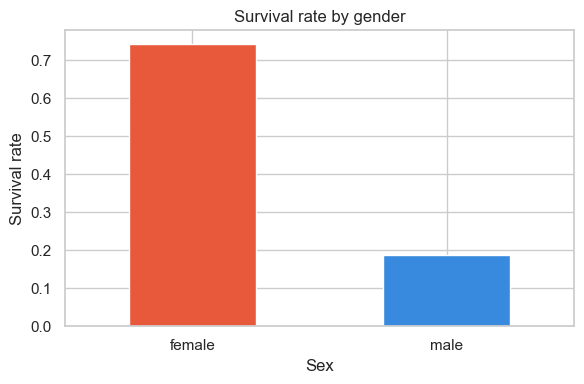

In [15]:
# Chart 1: Survival rate by gender (bar chart)
# Question: Did gender affect survival?
plt.figure(figsize=(6, 4))
df.groupby('Sex')['Survived'].mean().plot(kind='bar', color=['#E8593C', '#378ADD'])
plt.title('Survival rate by gender')
plt.ylabel('Survival rate')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_survival_gender.png', dpi=150)
plt.show()

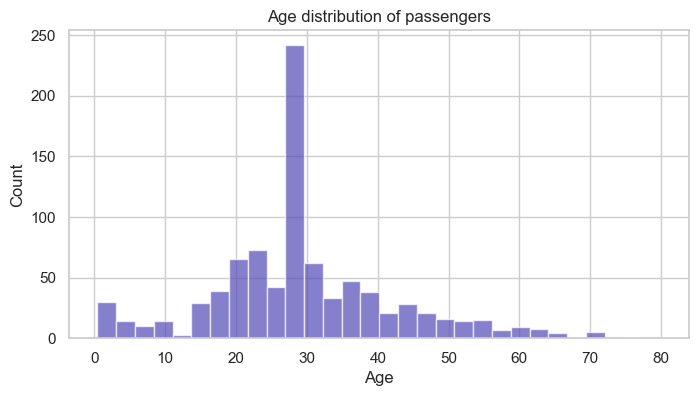

In [16]:
# Chart 2: Age distribution (histogram)
# Question: What ages were most passengers?
plt.figure(figsize=(8, 4))
df['Age'].hist(bins=30, color='#534AB7', alpha=0.7)
plt.title('Age distribution of passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.savefig('chart2_age_distribution.png', dpi=150)
plt.show()

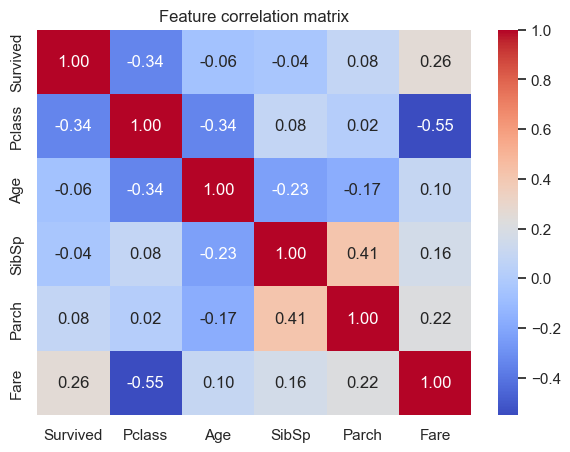

In [17]:
# Chart 3: Correlation heatmap
# Question: Which features are related to survival?
cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
plt.figure(figsize=(7, 5))
sns.heatmap(df[cols].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature correlation matrix')
plt.savefig('chart3_correlation.png', dpi=150)
plt.show()

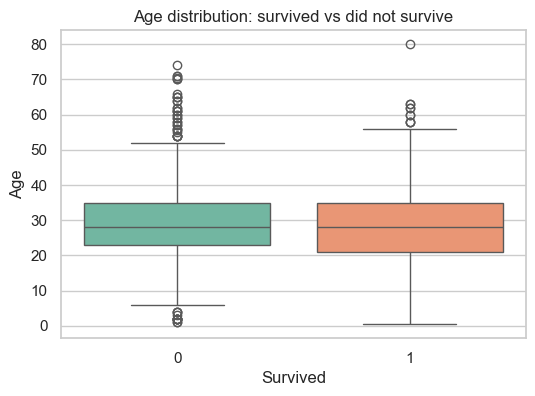

In [19]:
# Chart 4: Age by survival (boxplot)
# Question: Were survivors younger or older on average?
plt.figure(figsize=(6, 4))
sns.boxplot(x='Survived', y='Age', data=df, palette='Set2', hue='Survived', legend=False)
plt.title('Age distribution: survived vs did not survive')
plt.savefig('chart4_age_survival.png', dpi=150)
plt.show()

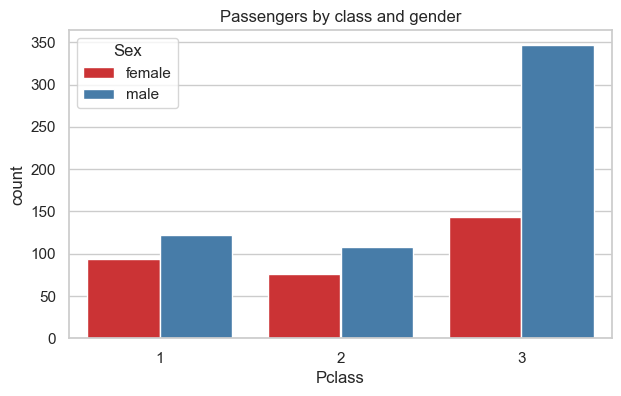

In [20]:
# Chart 5: Passenger count by class and gender (countplot)
# Question: Who was on the ship?
plt.figure(figsize=(7, 4))
sns.countplot(x='Pclass', hue='Sex', data=df, palette='Set1')
plt.title('Passengers by class and gender')
plt.savefig('chart5_class_gender.png', dpi=150)
plt.show()